In [41]:
import os

OUTPUT_DIR = "outputs"
FIG_DIR = "figures"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

In [1]:
# ==============================
# DAY 5 — BACKTEST SETTINGS
# ==============================

# Confidence levels
CONFIDENCE_LEVEL_95 = 0.95
CONFIDENCE_LEVEL_99 = 0.99

# Alpha (probability of loss beyond VaR)
ALPHA_95 = 1 - CONFIDENCE_LEVEL_95
ALPHA_99 = 1 - CONFIDENCE_LEVEL_99

# Backtest window (typical risk industry standard)
BACKTEST_WINDOW = 250  # ~1 trading year

# Convention:
# VaR will be stored as a POSITIVE loss number
# Example: VaR_95 = 0.02 means a 2% potential loss

# Breach rule:
# If the portfolio return is LESS than negative VaR, it is a breach
# Example:
# return = -0.03
# VaR = 0.02
# since -0.03 < -0.02 → breach occurs

print("Backtest settings loaded.")

Backtest settings loaded.


In [2]:
Inputs
Realized portfolio returns
Predicted VaR

Process
Check when losses exceed VaR

Output
Exception rate
Coverage tests
Model validation

SyntaxError: invalid syntax (2480448662.py, line 2)

In [3]:
import pandas as pd
import numpy as np

from sqlalchemy import create_engine, text

In [4]:
# ---- PostgreSQL connection ----
DB_USER = "YOUR_USERNAME"
DB_PASS = "YOUR_PASSWORD"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "equity_risk"   # <-- replace with your actual DB name

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

# Quick connection test
with engine.connect() as conn:
    print(conn.execute(text("SELECT 1")).fetchone())

ModuleNotFoundError: No module named 'psycopg2'

In [5]:
!pip install psycopg2-binary

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.7 MB 8.2 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 10.8 MB/s  0:00:00


In [9]:
from sqlalchemy import create_engine, text

DB_USER = "postgres"        # your username
DB_PASS = "laleh"   # your password
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "equity_risk_project"

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

with engine.connect() as conn:
    print(conn.execute(text("SELECT 1")).fetchone())

(1,)


In [10]:
import pandas as pd

q = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name;
"""

tables = pd.read_sql(q, engine)
tables

,table_name
0,portfolio_prices_long
1,portfolio_weights
2,returns


In [11]:
import pandas as pd

def show_cols(table):
    q = f"""
    SELECT column_name, data_type
    FROM information_schema.columns
    WHERE table_schema='public' AND table_name='{table}'
    ORDER BY ordinal_position;
    """
    return pd.read_sql(q, engine)

show_cols("returns")

,column_name,data_type
0,date,date
1,ticker,character varying
2,close_price,real
3,daily_return,double precision


In [12]:
show_cols("portfolio_weights")

,column_name,data_type
0,ticker,text
1,weight,numeric


In [13]:
show_cols("portfolio_prices_long")

,column_name,data_type
0,date,date
1,ticker,character varying
2,close_price,real


In [14]:
import pandas as pd
import numpy as np

# 1) Load tables
r = pd.read_sql("SELECT date, ticker, daily_return FROM returns;", engine)
w = pd.read_sql("SELECT ticker, weight FROM portfolio_weights;", engine)

# 2) Clean types
r["date"] = pd.to_datetime(r["date"])
r["daily_return"] = pd.to_numeric(r["daily_return"], errors="coerce")
w["weight"] = pd.to_numeric(w["weight"], errors="coerce")

# 3) Merge + compute weighted returns
df = r.merge(w, on="ticker", how="inner")
df["weighted_return"] = df["daily_return"] * df["weight"]

# 4) Aggregate to portfolio return by day
df_ret = (df.groupby("date", as_index=False)["weighted_return"]
            .sum()
            .rename(columns={"weighted_return": "portfolio_return"})
            .sort_values("date")
            .dropna()
            .reset_index(drop=True))

df_ret.head(), df_ret.tail(), df_ret.shape

(        date  portfolio_return
 0 2019-01-02          0.000000
 1 2019-01-03         -0.051894
 2 2019-01-04          0.045667
 3 2019-01-07          0.011638
 4 2019-01-08          0.002726,
            date  portfolio_return
 1505 2024-12-24          0.010134
 1506 2024-12-26          0.000210
 1507 2024-12-27         -0.014604
 1508 2024-12-30         -0.008787
 1509 2024-12-31         -0.008680,
 (1510, 2))

In [15]:
from scipy.stats import norm

# Keep last 250 trading days for backtest (or all if fewer)
df_bt = df_ret.copy().sort_values("date").reset_index(drop=True)
if len(df_bt) >= BACKTEST_WINDOW:
    df_bt = df_bt.tail(BACKTEST_WINDOW).reset_index(drop=True)

# Rolling estimation window (industry common; can tune later)
ROLL_WINDOW = 100

z_95 = norm.ppf(ALPHA_95)  # ~ -1.645
z_99 = norm.ppf(ALPHA_99)  # ~ -2.326

df_bt["mu"] = df_bt["portfolio_return"].rolling(ROLL_WINDOW).mean()
df_bt["sigma"] = df_bt["portfolio_return"].rolling(ROLL_WINDOW).std(ddof=1)

# VaR stored as POSITIVE loss number
df_bt["VaR_param_95"] = -(df_bt["mu"] + z_95 * df_bt["sigma"])
df_bt["VaR_param_99"] = -(df_bt["mu"] + z_99 * df_bt["sigma"])

# Drop early rows without enough history
df_bt = df_bt.dropna(subset=["VaR_param_95", "VaR_param_99"]).reset_index(drop=True)

df_bt[["date", "portfolio_return", "VaR_param_95", "VaR_param_99"]].tail(10)

,date,portfolio_return,VaR_param_95,VaR_param_99
141,2024-12-17,0.000198,0.019144,0.027644
142,2024-12-18,-0.026514,0.019885,0.028591
143,2024-12-19,0.005934,0.019568,0.028223
144,2024-12-20,0.015400,0.019369,0.027890
145,2024-12-23,0.008770,0.018655,0.027016
146,2024-12-24,0.010134,0.018225,0.026517
147,2024-12-26,0.000210,0.016548,0.024314
148,2024-12-27,-0.014604,0.016935,0.024745
149,2024-12-30,-0.008787,0.016935,0.024744
150,2024-12-31,-0.008680,0.016948,0.024623


In [16]:
# 1 = breach, 0 = no breach
df_bt["breach_95"] = (df_bt["portfolio_return"] < -df_bt["VaR_param_95"]).astype(int)
df_bt["breach_99"] = (df_bt["portfolio_return"] < -df_bt["VaR_param_99"]).astype(int)

df_bt[["date","portfolio_return","VaR_param_95","breach_95"]].tail(10)

,date,portfolio_return,VaR_param_95,breach_95
141,2024-12-17,0.000198,0.019144,0
142,2024-12-18,-0.026514,0.019885,1
143,2024-12-19,0.005934,0.019568,0
144,2024-12-20,0.015400,0.019369,0
145,2024-12-23,0.008770,0.018655,0
146,2024-12-24,0.010134,0.018225,0
147,2024-12-26,0.000210,0.016548,0
148,2024-12-27,-0.014604,0.016935,0
149,2024-12-30,-0.008787,0.016935,0
150,2024-12-31,-0.008680,0.016948,0


In [17]:
T = len(df_bt)

breaches_95 = df_bt["breach_95"].sum()
breaches_99 = df_bt["breach_99"].sum()

print("Total observations:", T)
print("95% breaches:", breaches_95)
print("99% breaches:", breaches_99)

print("95% breach rate:", breaches_95/T)
print("99% breach rate:", breaches_99/T)

Total observations: 151
95% breaches: 9
99% breaches: 6
95% breach rate: 0.059602649006622516
99% breach rate: 0.039735099337748346


In [49]:
plt.savefig(f"{FIG_DIR}/var_backtest_returns_vs_var.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

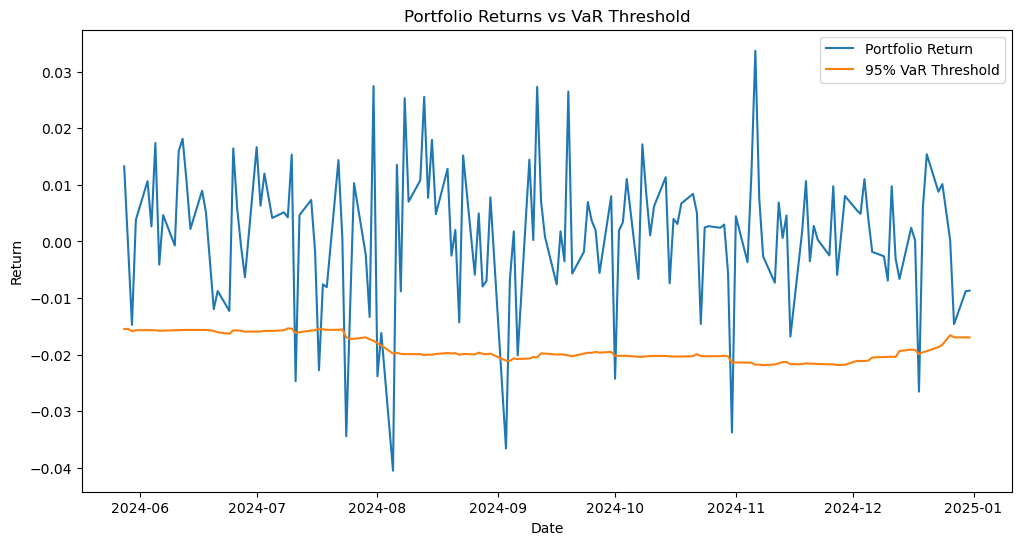

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df_bt["date"], df_bt["portfolio_return"], label="Portfolio Return")
plt.plot(df_bt["date"], -df_bt["VaR_param_95"], label="95% VaR Threshold")

plt.title("Portfolio Returns vs VaR Threshold")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()

plt.show()

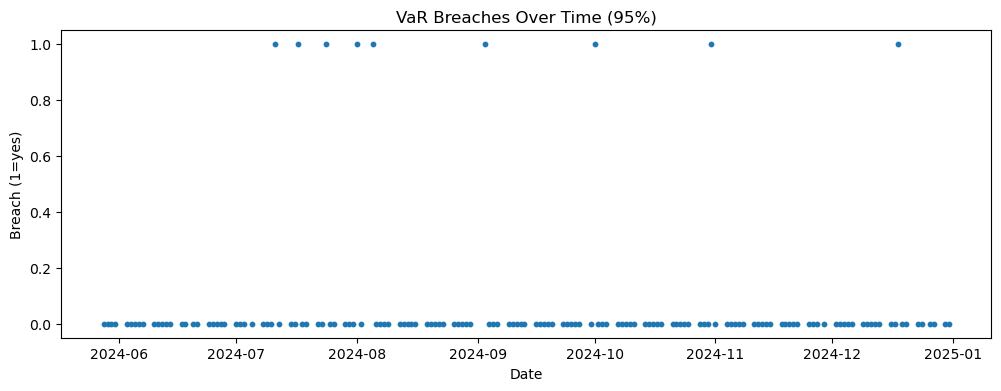

In [50]:
plt.figure(figsize=(12,4))

plt.scatter(df_bt["date"], df_bt["breach_95"], s=10)

plt.title("VaR Breaches Over Time (95%)")
plt.xlabel("Date")
plt.ylabel("Breach (1=yes)")
plt.savefig(f"{FIG_DIR}/var_breach_timeline.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
import numpy as np
from scipy.stats import chi2

def kupiec_test(breaches, alpha):
    
    T = len(breaches)
    x = breaches.sum()

    p_hat = x / T

    # Likelihood ratio statistic
    LR = -2 * (
        (T-x) * np.log((1-alpha)/(1-p_hat)) +
        x * np.log(alpha/p_hat)
    )

    p_value = 1 - chi2.cdf(LR, df=1)

    return T, x, p_hat, LR, p_value

In [22]:
T, x, p_hat, LR, p_val = kupiec_test(df_bt["breach_95"], ALPHA_95)

print("Observations:", T)
print("Breaches:", x)
print("Observed breach rate:", round(p_hat,4))
print("Kupiec LR statistic:", round(LR,4))
print("p-value:", round(p_val,4))

Observations: 151
Breaches: 9
Observed breach rate: 0.0596
Kupiec LR statistic: 0.2769
p-value: 0.5987


In [23]:
T, x, p_hat, LR, p_val = kupiec_test(df_bt["breach_99"], ALPHA_99)

print("Observations:", T)
print("Breaches:", x)
print("Observed breach rate:", round(p_hat,4))
print("Kupiec LR statistic:", round(LR,4))
print("p-value:", round(p_val,4))

Observations: 151
Breaches: 6
Observed breach rate: 0.0397
Kupiec LR statistic: 7.712
p-value: 0.0055


In [24]:
def basel_traffic_light(num_breaches_99):
    if num_breaches_99 <= 4:
        return "GREEN (0–4)"
    elif num_breaches_99 <= 9:
        return "YELLOW (5–9)"
    else:
        return "RED (10+)"

In [25]:
T = len(df_bt)
breaches_99 = int(df_bt["breach_99"].sum())
zone = basel_traffic_light(breaches_99)

print("Backtest observations:", T)
print("99% VaR breaches:", breaches_99)
print("Traffic Light Zone:", zone)

Backtest observations: 151
99% VaR breaches: 6
Traffic Light Zone: YELLOW (5–9)


In [26]:
# Kupiec results for 95% and 99%
T95, x95, p95, LR95, pv95 = kupiec_test(df_bt["breach_95"], ALPHA_95)
T99, x99, p99, LR99, pv99 = kupiec_test(df_bt["breach_99"], ALPHA_99)

summary = pd.DataFrame({
    "Model": ["Parametric", "Parametric"],
    "Confidence": ["95%", "99%"],
    "Days (T)": [T95, T99],
    "Breaches (x)": [x95, x99],
    "Breach Rate": [p95, p99],
    "Expected Alpha": [ALPHA_95, ALPHA_99],
    "Kupiec p-value": [pv95, pv99],
})

summary

,Model,Confidence,Days (T),Breaches (x),Breach Rate,Expected Alpha,Kupiec p-value
0,Parametric,95%,151,9,0.059603,0.05,0.598745
1,Parametric,99%,151,6,0.039735,0.01,0.005485


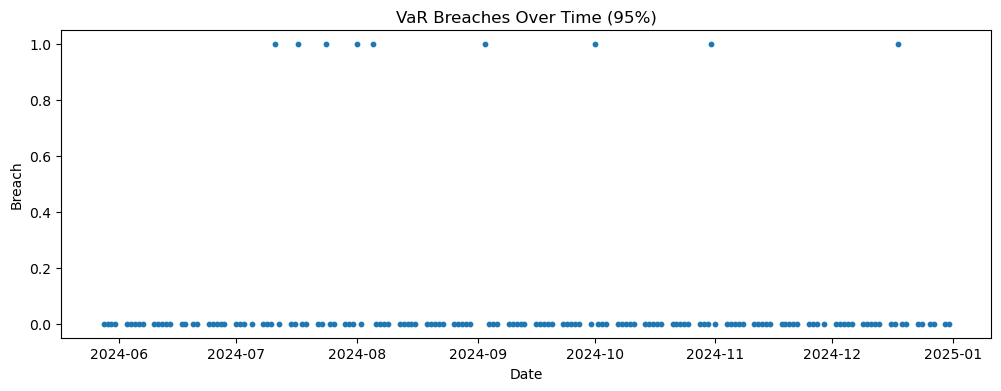

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.scatter(df_bt["date"], df_bt["breach_95"], s=10)

plt.title("VaR Breaches Over Time (95%)")
plt.xlabel("Date")
plt.ylabel("Breach")

plt.show()

In [28]:
breach_dates = df_bt.loc[df_bt["breach_95"] == 1, "date"]

days_between = breach_dates.diff().dt.days.dropna()

days_between.describe()

count     8.000000
mean     20.000000
std      16.008926
min       4.000000
25%       6.750000
50%      18.000000
75%      29.250000
max      48.000000
Name: date, dtype: float64

In [29]:
df_bt["breach_95"].autocorr(lag=1)

np.float64(-0.06382978723404248)

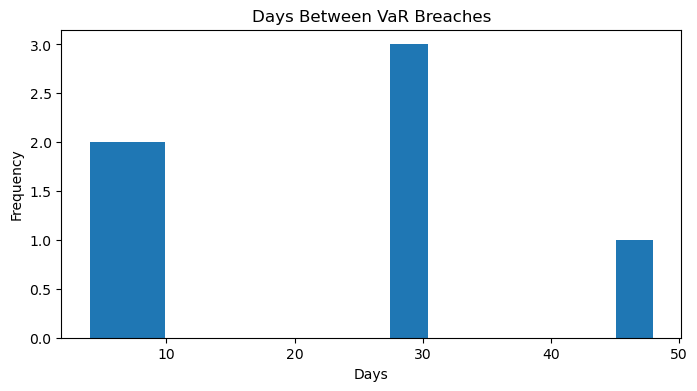

In [30]:
plt.figure(figsize=(8,4))

plt.hist(days_between, bins=15)

plt.title("Days Between VaR Breaches")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

In [31]:
alpha = ALPHA_95

# losses beyond VaR
tail_losses = df_bt[df_bt["portfolio_return"] < -df_bt["VaR_param_95"]]["portfolio_return"]

CVaR_95 = tail_losses.mean()

print("Expected Shortfall (CVaR 95%):", CVaR_95)

Expected Shortfall (CVaR 95%): -0.02968317535188463


In [32]:
ROLL_WINDOW = 100

df_bt["CVaR_95"] = (
    df_bt["portfolio_return"]
    .rolling(ROLL_WINDOW)
    .apply(lambda x: x[x < np.percentile(x, 5)].mean(), raw=False)
)

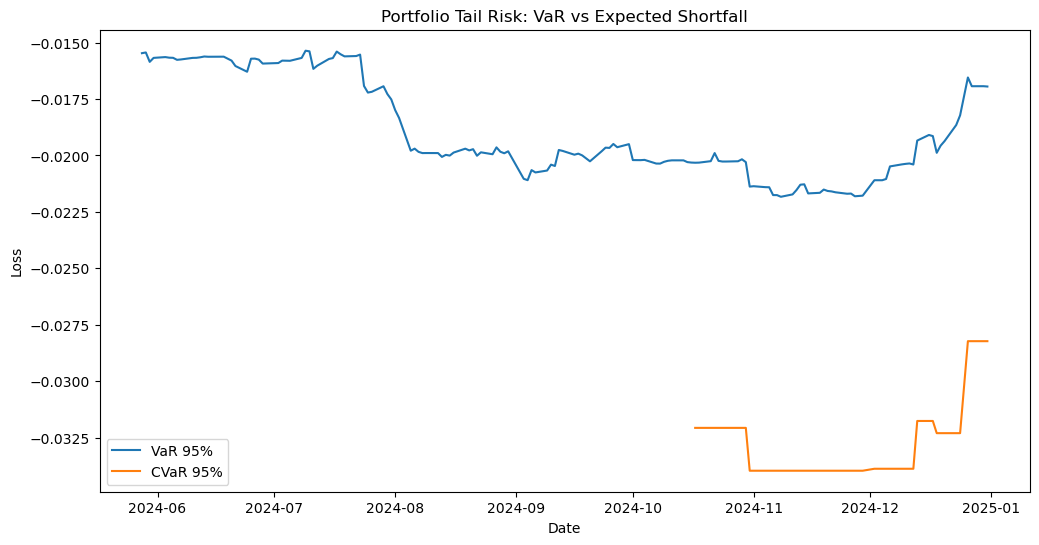

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df_bt["date"], -df_bt["VaR_param_95"], label="VaR 95%")
plt.plot(df_bt["date"], df_bt["CVaR_95"], label="CVaR 95%")

plt.title("Portfolio Tail Risk: VaR vs Expected Shortfall")
plt.xlabel("Date")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [34]:
tail_stats = {
    "Worst Loss": df_bt["portfolio_return"].min(),
    "VaR95 Average": df_bt["VaR_param_95"].mean(),
    "CVaR95 Average": df_bt["CVaR_95"].mean(),
}

tail_stats

{'Worst Loss': -0.04048382937908173,
 'VaR95 Average': np.float64(0.01892743062140954),
 'CVaR95 Average': np.float64(-0.0328611345589161)}

In [35]:
df_bt.to_csv("outputs/day6_tail_risk_panel.csv", index=False)

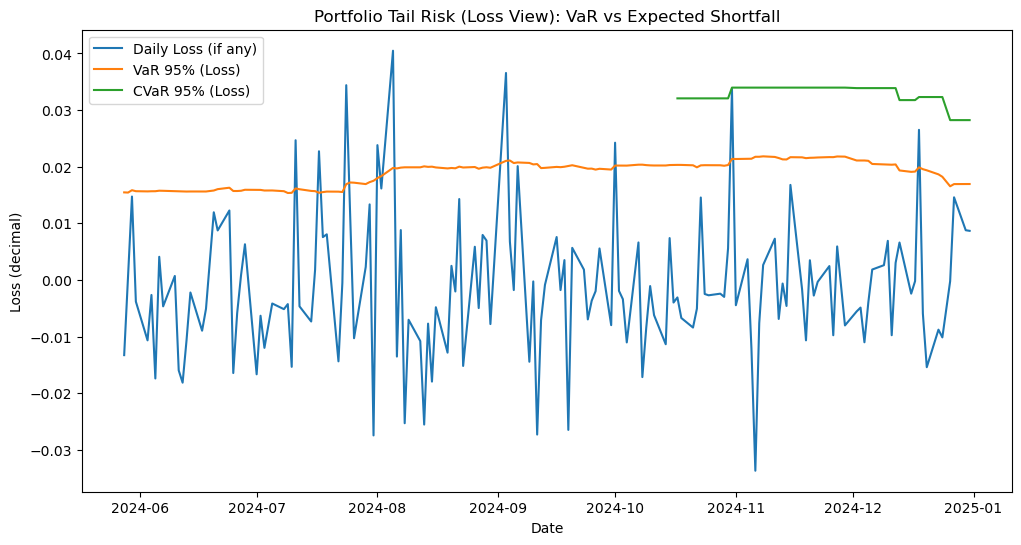

In [36]:
import matplotlib.pyplot as plt

plot_df = df_bt.copy()
plot_df["loss"] = -plot_df["portfolio_return"]      # convert returns to positive loss
plot_df["VaR95_loss"] = plot_df["VaR_param_95"]     # already positive
plot_df["CVaR95_loss"] = -plot_df["CVaR_95"]        # your CVaR series is negative

plt.figure(figsize=(12,6))
plt.plot(plot_df["date"], plot_df["loss"], label="Daily Loss (if any)")
plt.plot(plot_df["date"], plot_df["VaR95_loss"], label="VaR 95% (Loss)")
plt.plot(plot_df["date"], plot_df["CVaR95_loss"], label="CVaR 95% (Loss)")

plt.title("Portfolio Tail Risk (Loss View): VaR vs Expected Shortfall")
plt.xlabel("Date")
plt.ylabel("Loss (decimal)")
plt.legend()
plt.show()

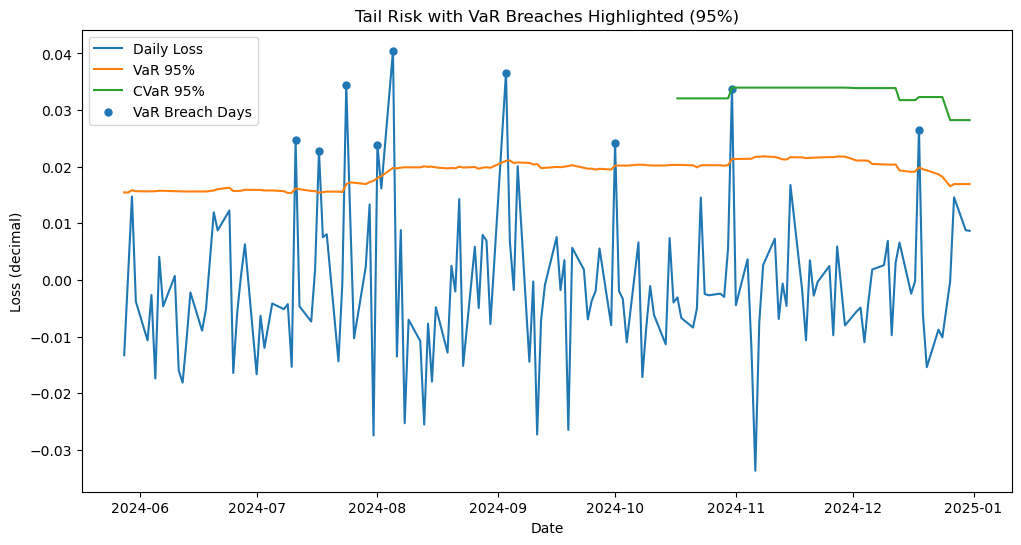

In [37]:
breach_pts = plot_df[df_bt["breach_95"] == 1]

plt.figure(figsize=(12,6))
plt.plot(plot_df["date"], plot_df["loss"], label="Daily Loss")
plt.plot(plot_df["date"], plot_df["VaR95_loss"], label="VaR 95%")
plt.plot(plot_df["date"], plot_df["CVaR95_loss"], label="CVaR 95%")

plt.scatter(breach_pts["date"], breach_pts["loss"], s=25, label="VaR Breach Days")

plt.title("Tail Risk with VaR Breaches Highlighted (95%)")
plt.xlabel("Date")
plt.ylabel("Loss (decimal)")
plt.legend()
plt.show()

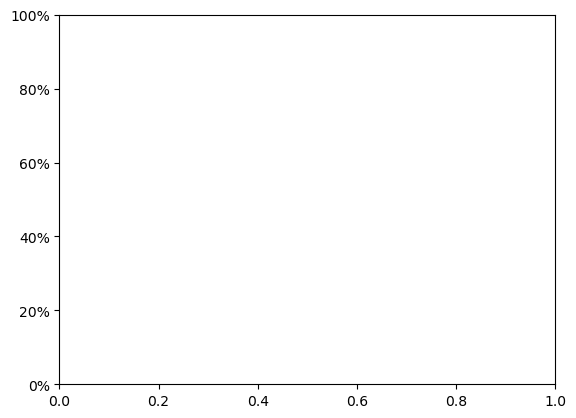

In [38]:
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

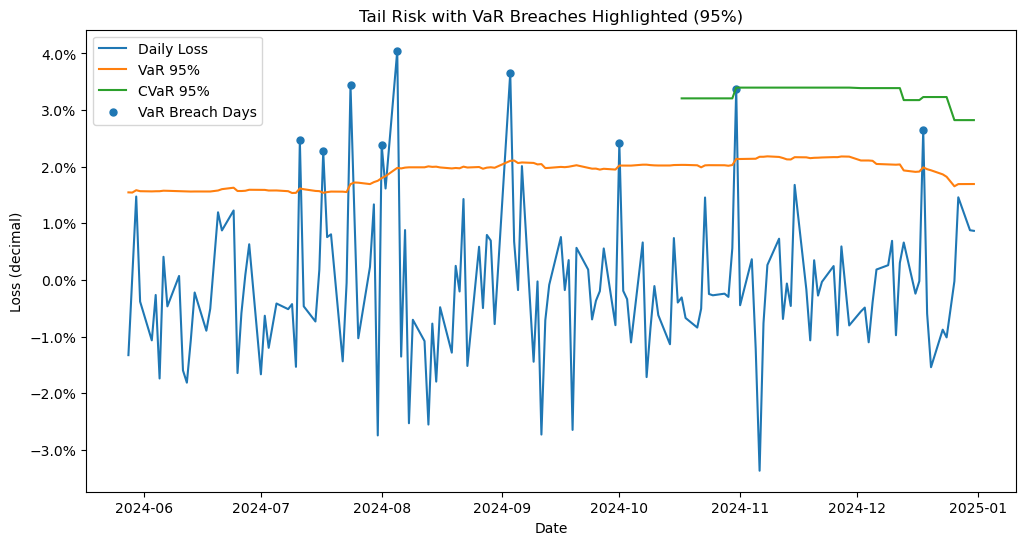

In [39]:
breach_pts = plot_df[df_bt["breach_95"] == 1]

plt.figure(figsize=(12,6))
plt.plot(plot_df["date"], plot_df["loss"], label="Daily Loss")
plt.plot(plot_df["date"], plot_df["VaR95_loss"], label="VaR 95%")
plt.plot(plot_df["date"], plot_df["CVaR95_loss"], label="CVaR 95%")

plt.scatter(breach_pts["date"], breach_pts["loss"], s=25, label="VaR Breach Days")

plt.title("Tail Risk with VaR Breaches Highlighted (95%)")
plt.xlabel("Date")
plt.ylabel("Loss (decimal)")
plt.legend()
import matplotlib.ticker as mtick
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

In [40]:
import os

OUTPUT_DIR = "outputs"
FIG_DIR = "figures"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

In [42]:
# Create the summary table
summary = pd.DataFrame({
    "Model": ["Parametric", "Parametric"],
    "Confidence": ["95%", "99%"],
    "Days (T)": [T95, T99],
    "Breaches (x)": [x95, x99],
    "Breach Rate": [p95, p99],
    "Expected Alpha": [ALPHA_95, ALPHA_99],
    "Kupiec p-value": [pv95, pv99],
})

summary

,Model,Confidence,Days (T),Breaches (x),Breach Rate,Expected Alpha,Kupiec p-value
0,Parametric,95%,151,9,0.059603,0.05,0.598745
1,Parametric,99%,151,6,0.039735,0.01,0.005485


In [43]:
summary.to_csv(f"{OUTPUT_DIR}/var_backtest_summary.csv", index=False)

In [44]:
df_bt

,date,portfolio_return,mu,sigma,VaR_param_95,VaR_param_99,breach_95,breach_99,CVaR_95
0,2024-05-28,0.013268,0.002819,0.011120,0.015472,0.023050,0,0,NaN
1,2024-05-29,-0.000746,0.002838,0.011112,0.015440,0.023013,0,0,NaN
2,2024-05-30,-0.014737,0.002647,0.011249,0.015856,0.023522,0,0,NaN
3,2024-05-31,0.003812,0.002430,0.011010,0.015680,0.023183,0,0,NaN
4,2024-06-03,0.010659,0.002515,0.011040,0.015645,0.023169,0,0,NaN
...,...,...,...,...,...,...,...,...,...
146,2024-12-24,0.010134,0.001788,0.012167,0.018225,0.026517,0,0,-0.032306
147,2024-12-26,0.000210,0.002195,0.011395,0.016548,0.024314,0,0,-0.028231
148,2024-12-27,-0.014604,0.001914,0.011459,0.016935,0.024745,0,0,-0.028231
149,2024-12-30,-0.008787,0.001914,0.011459,0.016935,0.024744,0,0,-0.028231


In [45]:
df_bt.to_csv(f"{OUTPUT_DIR}/daily_var_backtest_panel.csv", index=False)

In [46]:
plot code
save figure
show figure

SyntaxError: invalid syntax (4239030602.py, line 1)

TypeError: float() argument must be a string or a real number, not 'ellipsis'

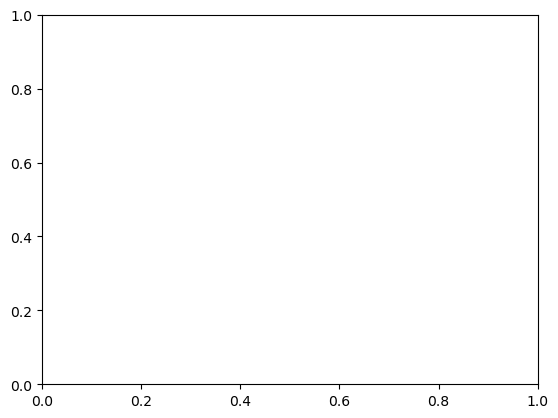

In [47]:
plt.plot(...)
plt.savefig(f"{FIG_DIR}/var_breach_timeline.png", dpi=300, bbox_inches="tight")
plt.show()

In [48]:
plt.show()